# Лекция: Компьютерное зрение
## Self-Supervised Learning & Metric Learning

**Преподаватель:** Весельев Александр, Т-Банк

**Аудитория:** ФКН ВШЭ, МФТИ

---

## Содержание

1. self-supervised learning models
   1. SimCLR
   2. BYOL
   3. BEiT
   4. iBOT
   5. Dinov1
   6. Dinov2
   7. Dinov3
2. Contrastive Learning
   1. CLIP
   2. SigLIP
   3. SigLIP2
      1. linear probing
3. Metric Learning
   1. Tasks
      1. Verification
      2. Identification
         1. ReID
   2. Metrics
      1. RocAUC, TAR/FAR
      2. recall@k
      3. mAP
      4. CMC
      5. precision@k
   3. Triplet Loss
      1. HNM, OHNM
   4. FaceLoss
      1. CosFace
      2. SphereFace
      3. ArcFace
      4. AdaFace
      5. PartialFC
   5. ANN
      1. K-D tree
      2. HNSW
      3. LSH
      4. IVF-PQ
      5. Libs (Annoy, FAISS, HNSWlib, Qdrant)

## 1. Self-Supervised Learning

### 1.1 SimCLR

[arxiv](https://arxiv.org/abs/2002.05709)

![./assets/simclr.png](./assets/simclr.png)

**Идея**

Self-Supervised метод обучения:
- Учим сеть предсказывать одинаковые эмбединги для семантически одинаковых изображений (с разными аугментациями)


**Псевдокод**

```python
# input:
#   N   - batch size
#   tau - temperature constant
#   f   - encoder network
#   g   - projection head
#   T   - family of augmentations

for batch in dataloader:  # batch = {x_k}_{k=1}^N
    x = batch  # x[0], ..., x[N-1]

    h = [None] * (2 * N)
    z = [None] * (2 * N)

    for k in range(N):
        t1 = sample_augmentation(T)
        t2 = sample_augmentation(T)

        # first augmentation
        x_2k_1 = t1(x[k])
        h[2 * k] = f(x_2k_1)  # representation
        z[2 * k] = g(h[2 * k])  # projection

        # second augmentation
        x_2k = t2(x[k])
        h[2 * k + 1] = f(x_2k)  # representation
        z[2 * k + 1] = g(h[2 * k + 1])  # projection

    s = [[0.0 for _ in range(2 * N)] for _ in range(2 * N)]

    for i in range(2 * N):
        for j in range(2 * N):
            s[i][j] = cosine_similarity(z[i], z[j])

    def l(i, j):
        numerator = exp(s[i][j] / tau)

        denominator = 0.0
        for k in range(2 * N):
            if k != i:
                denominator += exp(s[i][k] / tau)

        return -log(numerator / denominator)

    L = 0.0
    for k in range(N):
        L += l(2 * k, 2 * k + 1) + l(2 * k + 1, 2 * k)

    L = L / (2 * N)

    update(f, g, loss=L)
return f
```

## 1.2 BYOL

[arxiv](https://arxiv.org/abs/2006.07733)

![./assets/byol.png](assets/byol.png)


**Идея**

Две аугментации одной и той же картинки: одна сеть (online) пытается предсказать представление второй (target), а вторая сеть даёт целевой вектор и обновляется не градиентом, а как медленная средняя от первой сети (EMA). Главное отличие от SimCLR: BYOL не использует negative pairs


**Псевдокод**
```python
# input:
#   D      - dataset
#   T, T2  - distributions of augmentations
#   f_o    - online encoder
#   g_o    - online projector
#   q_o    - online predictor
#   f_t    - target encoder
#   g_t    - target projector
#   tau_k  - EMA coefficient schedule
#   eta_k  - learning rate schedule

for k in range(1, K + 1):
    batch = sample_batch(D, size=N)

    losses = []

    for x in batch:
        t1 = sample_augmentation(T)
        t2 = sample_augmentation(T2)

        # two views of the same image
        v1 = t1(x)
        v2 = t2(x)

        # online network
        z1 = g_o(f_o(v1))
        z2 = g_o(f_o(v2))

        p1 = q_o(z1)
        p2 = q_o(z2)

        # target network
        z1_target = g_t(f_t(v1))
        z2_target = g_t(f_t(v2))

        # symmetrized loss
        loss_1 = -2 * cosine_similarity(p1, stop_gradient(z2_target))
        loss_2 = -2 * cosine_similarity(p2, stop_gradient(z1_target))

        loss = loss_1 + loss_2
        losses.append(loss)

    L = mean(losses)

    # update online network with gradient descent
    update_parameters([f_o, g_o, q_o], loss=L, lr=eta_k)

    # update target network with exponential moving average
    for param_t, param_o in zip(target_params, online_params):
        param_t = tau_k * param_t + (1 - tau_k) * param_o

# keep only the online encoder
return f_o
```

## 1.3 BEiT: BERT Pre-Training of Image Transformers

[arxiv](https://arxiv.org/abs/2106.08254)

![./assets/beit.png](./assets/beit.png)

**Идея**

Картинку режут на патчи, часть патчей маскируют, а модель должна угадать не сами пиксели, а дискретные "визуальные токены" для скрытых частей изображения. Эти токены заранее получает отдельный image tokenizer, обученный как dVAE (взято отсюда https://github.com/openai/DALL-E)

**Псевдокод**

```python
# input:
#   images            - training dataset
#   tokenizer         - pretrained image tokenizer
#   model             - Vision Transformer
#   mask_ratio        - fraction of patches to mask
#   optimizer         - optimizer for model parameters

for epoch in range(num_epochs):
    for image in dataloader(images):

        # 1. split image into patches
        patches = split_into_patches(image)

        # 2. get target visual tokens from tokenizer
        with no_grad():
            target_tokens = tokenizer.encode(image)

        # 3. sample masked patch positions
        masked_positions = sample_mask_positions(
            num_patches=len(patches),
            mask_ratio=mask_ratio
        )

        # 4. replace selected patches with [MASK]
        input_patches = []
        for i, patch in enumerate(patches):
            if i in masked_positions:
                input_patches.append(MASK_PATCH)
            else:
                input_patches.append(patch)

        # 5. encode visible + masked patches with ViT
        hidden_states = model(input_patches)

        # 6. predict visual tokens only for masked patches
        logits = predict_tokens(hidden_states)   # shape: num_patches x vocab_size

        # 7. compute loss only on masked positions
        loss = cross_entropy(
            logits[masked_positions],
            target_tokens[masked_positions]
        )

        # 8. update model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# after pretraining, use the encoder for downstream tasks
return model.encoder
```

## 1.4 iBOT: Image BERT Pre-Training with Online Tokenizer

[arxiv](https://arxiv.org/abs/2111.07832)

![./assets/ibot.png](./assets/ibot.png)

**Идея**

Модель учится понимать всю картинку целиком и одновременно учится предсказывать скрытые патчи изображения. iBOT не нужен отдельный заранее обученный токенизатор, потому что teacher network сам выдаёт целевые токены для обучения

**Псевдокод**

```python
# input:
#   student_encoder
#   student_proj_cls       # projector/head for CLS token
#   student_proj_patch     # projector/head for patch tokens
#   teacher_encoder
#   teacher_proj_cls
#   teacher_proj_patch
#   mask_ratio
#   tau_s, tau_t           # temperatures for student / teacher
#   m                      # EMA momentum for teacher update

for batch in dataloader:
    loss_batch = 0.0

    for x in batch:
        # 1. sample two views of the same image
        view_s = strong_augmentation(x)   # for student
        view_t = weak_augmentation(x)     # for teacher

        # 2. create masked student input
        mask = sample_masked_patches(view_s, mask_ratio)
        masked_view_s = apply_mask(view_s, mask)

        # 3. forward pass through student
        cls_s, patch_s = student_encoder(masked_view_s)
        y_cls_s = student_proj_cls(cls_s)
        y_patch_s = student_proj_patch(patch_s)

        # 4. forward pass through teacher
        # teacher usually sees unmasked / less masked view
        with no_gradient():
            cls_t, patch_t = teacher_encoder(view_t)
            y_cls_t = teacher_proj_cls(cls_t)
            y_patch_t = teacher_proj_patch(patch_t)

        # 5. convert teacher outputs to targets
        target_cls = softmax(y_cls_t / tau_t)
        target_patch = softmax(y_patch_t / tau_t)

        # 6. convert student outputs to predictions
        pred_cls = log_softmax(y_cls_s / tau_s)
        pred_patch = log_softmax(y_patch_s / tau_s)

        # 7. global loss on CLS token
        loss_cls = cross_entropy(target_cls, pred_cls)

        # 8. patch loss only on masked positions
        loss_patch = 0.0
        for i in masked_positions(mask):
            loss_patch += cross_entropy(target_patch[i], pred_patch[i])
        loss_patch /= number_of_masked_positions(mask)

        # 9. total loss
        loss = loss_cls + loss_patch
        loss_batch += loss

    loss_batch /= len(batch)

    # 10. update student by gradient descent
    optimizer.zero_grad()
    loss_batch.backward()
    optimizer.step()

    # 11. update teacher by exponential moving average
    for theta_t, theta_s in zip(teacher_parameters, student_parameters):
        theta_t = m * theta_t + (1 - m) * theta_s

return student_encoder
```

## 1.5 Dino

### DinoV1

[arxiv](https://arxiv.org/abs/2104.14294)

![./assets/dinov1.png](assets/dinov1.png)

**Псевдокод**

```python
# gs : student network
# gt : teacher network
# C  : center vector, shape [K]
# tps: student temperature
# tpt: teacher temperature
# l  : teacher momentum
# m  : center momentum

gt.params = gs.params.copy()

for x in loader:
    x1 = augment(x)
    x2 = augment(x)

    s1 = gs(x1)  # student outputs, shape [n, K]
    s2 = gs(x2)

    t1 = gt(x1)  # teacher outputs, shape [n, K]
    t2 = gt(x2)

    loss = H(t1, s2) / 2 + H(t2, s1) / 2

    optimizer.zero_grad()
    loss.backward()  # back-propagate through student only
    optimizer.step()  # update student

    # teacher update: exponential moving average of student
    for p_t, p_s in zip(gt.params, gs.params):
        p_t.data = l * p_t.data + (1 - l) * p_s.data

    # center update
    batch_center = concat([t1, t2]).mean(dim=0)
    C = m * C + (1 - m) * batch_center


def H(t, s):
    t = detach(t)  # stop gradient on teacher
    s = softmax(s / tps, dim=1)  # student probabilities
    t = softmax((t - C) / tpt, dim=1)  # teacher centering + sharpening
    return -(t * log(s)).sum(dim=1).mean()
```

### DinoV2

[arxiv](https://arxiv.org/abs/2304.07193)

*Отличие с v1*

- на порядок больше данных (~142M изображений)
- добавлен patch-loss (iBOT)
- Sinkhorn-Knopp для teacher targets (замена centering)
- KoLEO регуляризация

### DinoV3

[arxiv](https://arxiv.org/abs/2508.10104)

*Отличие с v2*

- Еще больше данных (~1B изображений)
- Gram anchoring (модель учит взаимосвязь признаков)
- Обновление positional endoding, стабильнее обучение


In [2]:
import truststore

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import ViTImageProcessor, ViTModel


truststore.inject_into_ssl()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dinov1_processor = ViTImageProcessor.from_pretrained("facebook/dino-vitb8")
dinov1_model = ViTModel.from_pretrained(
    "facebook/dino-vitb8",
    attn_implementation="eager",
).to(device)


KeyboardInterrupt: 

**Dino V1 visualization**

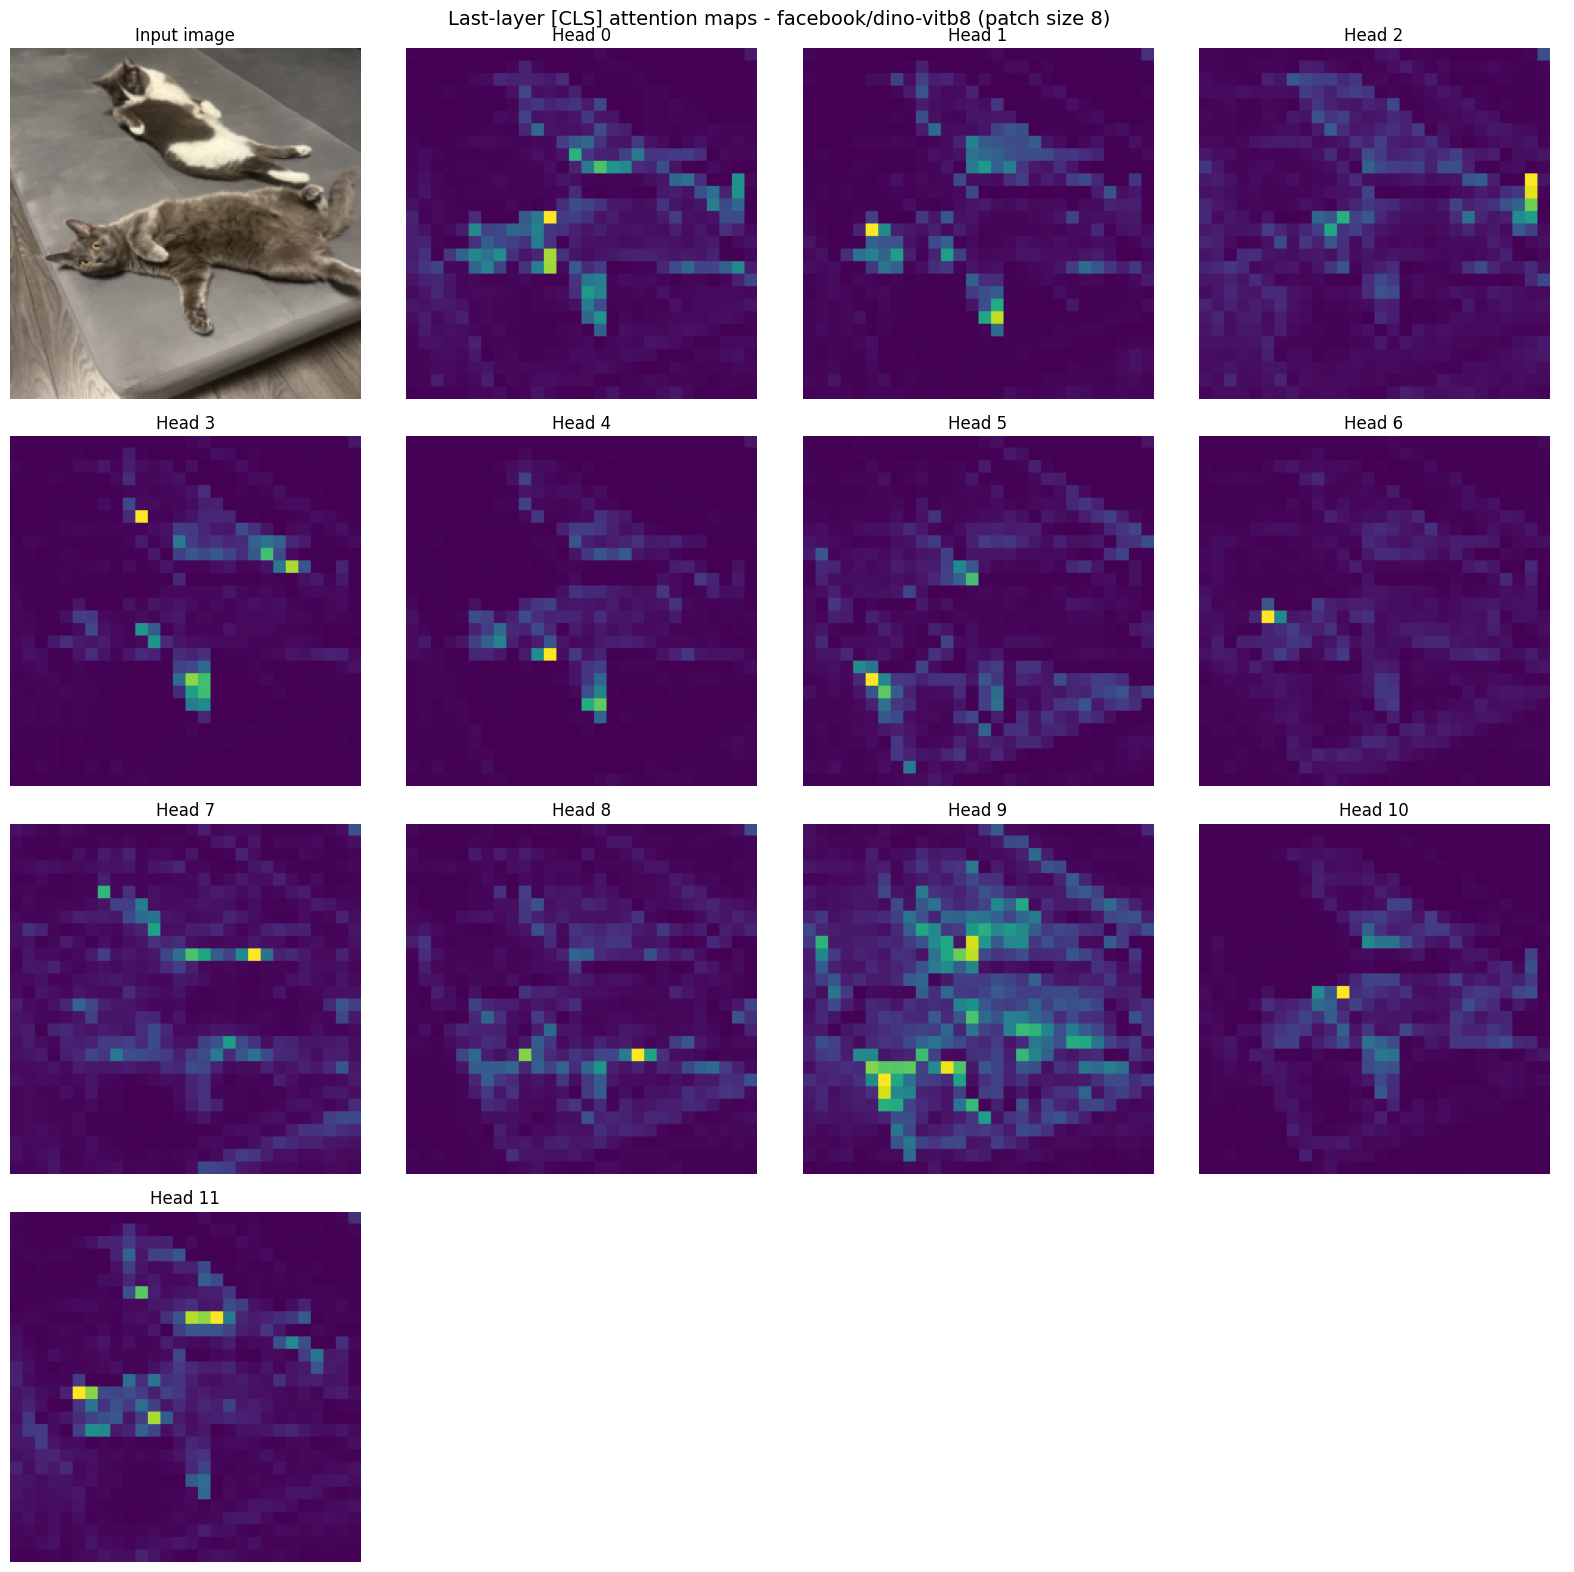

In [ ]:
def load_image(image_path: str) -> Image.Image:
    img = Image.open(image_path).convert("RGB")
    return img


def minmax_norm(x: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    x_min = x.amin(dim=(-2, -1), keepdim=True)
    x_max = x.amax(dim=(-2, -1), keepdim=True)
    return (x - x_min) / (x_max - x_min + eps)


@torch.no_grad()
def get_last_layer_cls_attention(
    image: Image.Image,
    model: ViTModel,
    processor: ViTImageProcessor,
    device: torch.device,
):
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    outputs = model(pixel_values=pixel_values, output_attentions=True)
    # Shape: [batch, heads, tokens, tokens]
    last_attn = outputs.attentions[-1]

    # Shape: [heads, num_patches]
    cls_attn = last_attn[0, :, 0, 1:]

    h, w = pixel_values.shape[-2:]
    patch_size = model.config.patch_size
    grid_h = h // patch_size
    grid_w = w // patch_size

    # Shape: [heads, grid_h, grid_w]
    cls_attn = cls_attn.reshape(model.config.num_attention_heads, grid_h, grid_w)
    cls_attn = minmax_norm(cls_attn)

    return cls_attn.cpu(), (h, w), patch_size


def visualise_dinov1(model: ViTModel, processor: ViTImageProcessor, input_image_path: str) -> None:
    model.eval()

    image = load_image(input_image_path)

    cls_attn, processed_size, patch_size = get_last_layer_cls_attention(
        image=image,
        model=model,
        processor=processor,
        device=device,
    )

    processed = processor(images=image, return_tensors="pt")["pixel_values"][0]
    display_img = processed.permute(1, 2, 0).cpu().numpy()

    mean = np.array(processor.image_mean, dtype=np.float32)
    std = np.array(processor.image_std, dtype=np.float32)
    display_img = (display_img * std) + mean
    display_img = np.clip(display_img, 0.0, 1.0)

    attn_up = F.interpolate(
        cls_attn.unsqueeze(1),  # [heads, 1, gh, gw]
        size=processed_size,
        mode="nearest",
    ).squeeze(1)  # [heads, H, W]

    num_heads = attn_up.shape[0]

    cols = 4
    rows = int(np.ceil((num_heads + 1) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(rows, cols)

    axes[0, 0].imshow(display_img)
    axes[0, 0].set_title("Input image")
    axes[0, 0].axis("off")

    for head_idx in range(num_heads):
        r = (head_idx + 1) // cols
        c = (head_idx + 1) % cols

        attn_map = attn_up[head_idx].cpu().numpy()

        axes[r, c].imshow(attn_map, cmap="viridis")
        axes[r, c].set_title(f"Head {head_idx}")
        axes[r, c].axis("off")

    total_slots = rows * cols
    used_slots = num_heads + 1
    for k in range(used_slots, total_slots):
        r = k // cols
        c = k % cols
        axes[r, c].axis("off")

    fig.suptitle(
        f"Last-layer [CLS] attention maps - facebook/dino-vitb8 (patch size {patch_size})",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


visualise_dinov1(model=dinov1_model, processor=dinov1_processor, input_image_path="../lesson_5/assets/cats.jpg")

**Dino V2 visualization**

In [ ]:
from pathlib import Path
from typing import List, Sequence, Tuple

from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel


dinov2_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dinov2_model = AutoModel.from_pretrained(
    "facebook/dinov2-base",
).to(device)


The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

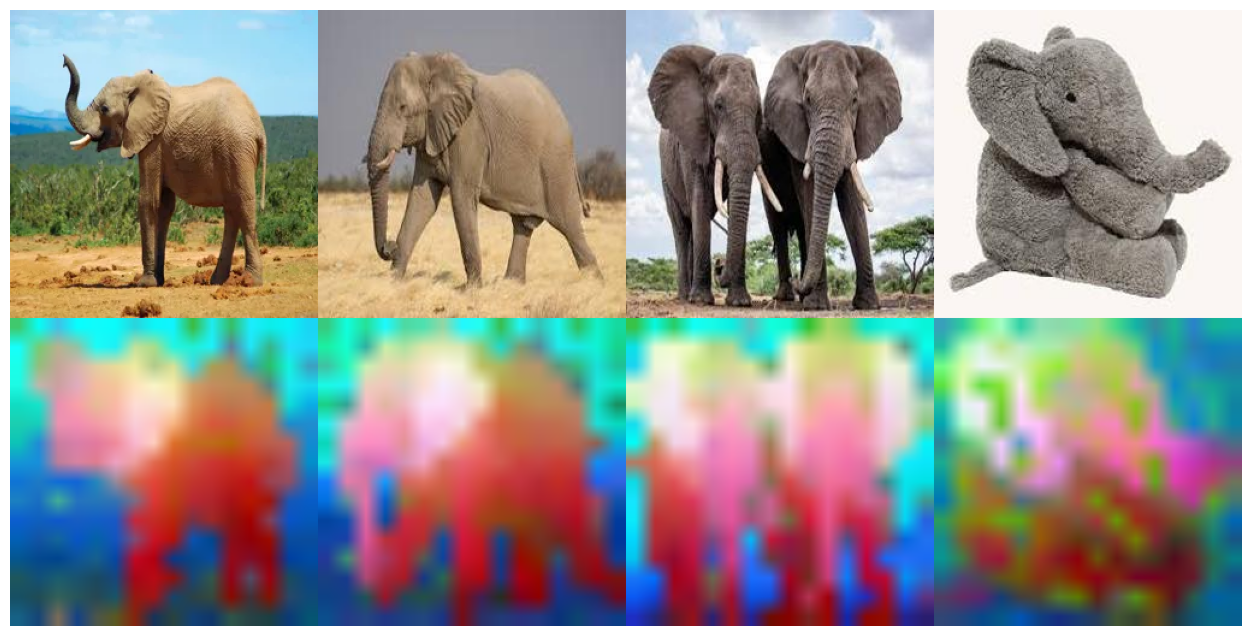

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


def list_images(directory: Path) -> List[Path]:
    if not directory.exists() or not directory.is_dir():
        raise FileNotFoundError(f"Input directory does not exist or is not a directory: {directory}")

    paths = sorted(p for p in directory.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
    if len(paths) < 2:
        raise ValueError(f"Need at least 2 images in {directory}, found {len(paths)}.")
    if not (3 <= len(paths) <= 5):
        print(f"[warning] Expected 3-5 images, found {len(paths)}. Proceeding anyway.")
    return paths


def load_images(paths: Sequence[Path]) -> List[Image.Image]:
    images: List[Image.Image] = []
    for path in paths:
        with Image.open(path) as img:
            images.append(img.convert("RGB"))
    return images


def infer_patch_grid(num_patches: int) -> Tuple[int, int]:
    side = int(round(num_patches ** 0.5))
    if side * side != num_patches:
        raise ValueError(f"Number of patches ({num_patches}) is not a perfect square.")
    return side, side


@torch.no_grad()
def extract_patch_tokens(
    model: AutoModel,
    processor: AutoImageProcessor,
    images: Sequence[Image.Image],
    device: str,
) -> Tuple[List[np.ndarray], List[Tuple[int, int]], List[Tuple[int, int]]]:
    patch_tokens_per_image: List[np.ndarray] = []
    patch_grids: List[Tuple[int, int]] = []
    original_sizes: List[Tuple[int, int]] = []

    for image in images:
        original_sizes.append((image.height, image.width))
        inputs = processor(images=image, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(device)

        outputs = model(pixel_values=pixel_values)
        hidden = outputs.last_hidden_state  # [1, 1 + num_patches, dim]
        patch_tokens = hidden[:, 1:, :].squeeze(0).cpu().numpy()  # drop CLS token

        h_patches, w_patches = infer_patch_grid(patch_tokens.shape[0])
        patch_tokens_per_image.append(patch_tokens)
        patch_grids.append((h_patches, w_patches))

    return patch_tokens_per_image, patch_grids, original_sizes


def fit_joint_pca(patch_tokens_per_image: Sequence[np.ndarray]) -> Tuple[PCA, np.ndarray]:
    joint_tokens = np.concatenate(patch_tokens_per_image, axis=0)
    pca = PCA(n_components=3, svd_solver="full")
    joint_pca = pca.fit_transform(joint_tokens)
    return pca, joint_pca


def robust_minmax(x: np.ndarray, low_q: float = 0.01, high_q: float = 0.99) -> np.ndarray:
    lo = np.quantile(x, low_q, axis=0, keepdims=True)
    hi = np.quantile(x, high_q, axis=0, keepdims=True)
    denom = np.maximum(hi - lo, 1e-8)
    y = (x - lo) / denom
    return np.clip(y, 0.0, 1.0)


def split_joint_projection(joint_projection: np.ndarray, counts: Sequence[int]) -> List[np.ndarray]:
    out: List[np.ndarray] = []
    start = 0
    for count in counts:
        out.append(joint_projection[start:start + count])
        start += count
    return out


def projection_to_rgb_map(proj: np.ndarray, patch_grid: Tuple[int, int]) -> np.ndarray:
    rgb = robust_minmax(proj)
    h_patches, w_patches = patch_grid
    return rgb.reshape(h_patches, w_patches, 3)


def upsample_patch_map(rgb_map: np.ndarray, out_hw: Tuple[int, int]) -> np.ndarray:
    tensor = torch.from_numpy(rgb_map).permute(2, 0, 1).unsqueeze(0).float()
    up = F.interpolate(tensor, size=out_hw, mode="bilinear", align_corners=False)
    up = up.squeeze(0).permute(1, 2, 0).numpy()
    up = np.clip(up * 255.0, 0, 255).astype(np.uint8)
    return up


def mask_from_pc1(pc1: np.ndarray, patch_grid: Tuple[int, int], q: float) -> np.ndarray:
    threshold = np.quantile(pc1, q)
    mask = (pc1 > threshold).astype(np.float32)
    h_patches, w_patches = patch_grid
    return mask.reshape(h_patches, w_patches)


def upsample_mask(mask: np.ndarray, out_hw: Tuple[int, int]) -> np.ndarray:
    tensor = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)
    up = F.interpolate(tensor, size=out_hw, mode="nearest")
    return up.squeeze(0).squeeze(0).numpy()


def apply_mask(rgb_img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    masked = rgb_img.astype(np.float32) * mask[..., None]
    return np.clip(masked, 0, 255).astype(np.uint8)


def save_image(array: np.ndarray, path: Path) -> None:
    Image.fromarray(array).save(path)


def make_grid(rows: List[List[Image.Image]]) -> Image.Image:
    n_cols = max(len(row) for row in rows)
    cell_widths = [max(row[c].width for row in rows if c < len(row)) for c in range(n_cols)]
    cell_heights = [max(img.height for img in row) for row in rows]

    total_w = sum(cell_widths)
    total_h = sum(cell_heights)
    canvas = Image.new("RGB", (total_w, total_h), color=(255, 255, 255))

    y = 0
    for r, row in enumerate(rows):
        x = 0
        for c, img in enumerate(row):
            canvas.paste(img, (x, y))
            x += cell_widths[c]
        y += cell_heights[r]
    return canvas


def visualise_dinov2(model: AutoModel, processor: AutoImageProcessor, input_directory: Path) -> None:
    image_paths = list_images(input_directory)
    images = load_images(image_paths)

    model.eval()

    patch_tokens_per_image, patch_grids, original_sizes = extract_patch_tokens(
        model=model,
        processor=processor,
        images=images,
        device=device,
    )

    _, joint_projection = fit_joint_pca(patch_tokens_per_image)
    counts = [x.shape[0] for x in patch_tokens_per_image]
    split_projection = split_joint_projection(joint_projection, counts)

    original_row: List[Image.Image] = []
    pca_row: List[Image.Image] = []

    for image, proj, patch_grid, out_hw in zip(
        images, split_projection, patch_grids, original_sizes
    ):
        rgb_map = projection_to_rgb_map(proj, patch_grid)
        rgb_up = upsample_patch_map(rgb_map, out_hw)

        original_row.append(image)
        pca_row.append(Image.fromarray(rgb_up))
        
    grid = make_grid([original_row, pca_row])
    
    plt.figure(figsize=(16, 8))
    plt.imshow(np.array(grid))
    plt.axis("off")
    plt.show()


visualise_dinov2(dinov2_model, dinov2_processor, Path("assets/dinov2"))

**Dino V3 visualization**

In [ ]:
# from huggingface_hub import login


# login()


def pick_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def pick_dtype(device: torch.device) -> torch.dtype:
    if device.type == "cuda":
        if torch.cuda.is_bf16_supported():
            return torch.bfloat16
        return torch.float16
    return torch.float32


device = pick_device()
dtype = pick_dtype(device=device)
dinov3_model = AutoModel.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m", dtype=dtype).to(device)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [ ]:
import math
from dataclasses import dataclass
from typing import List, Sequence, Tuple

from PIL import Image, ImageDraw


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


@dataclass(frozen=True)
class ParsedPoint:
    x: int
    y: int


def ensure_rgb(image: Image.Image) -> Image.Image:
    if image.mode != "RGB":
        image = image.convert("RGB")
    return image


def pil_to_normalized_tensor(image: Image.Image) -> torch.Tensor:
    arr = np.asarray(image).astype(np.float32) / 255.0
    if arr.ndim != 3 or arr.shape[2] != 3:
        raise ValueError(f"Expected RGB image, got array with shape {arr.shape}")
    tensor = torch.from_numpy(arr).permute(2, 0, 1).contiguous()
    mean = torch.tensor(IMAGENET_MEAN, dtype=tensor.dtype).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, dtype=tensor.dtype).view(3, 1, 1)
    return (tensor - mean) / std


def pad_image_to_multiple(image: Image.Image, multiple: int) -> Tuple[Image.Image, Tuple[int, int]]:
    w, h = image.size
    new_w = int(math.ceil(w / multiple) * multiple)
    new_h = int(math.ceil(h / multiple) * multiple)
    pad_w = new_w - w
    pad_h = new_h - h
    if pad_w == 0 and pad_h == 0:
        return image, (0, 0)
    canvas = Image.new("RGB", (new_w, new_h), (0, 0, 0))
    canvas.paste(image, (0, 0))
    return canvas, (pad_w, pad_h)


@torch.inference_mode()
def extract_patch_features_single_pass(
    model: AutoModel,
    image: Image.Image,
    device: torch.device,
    dtype: torch.dtype,
) -> torch.Tensor:
    patch_size = int(model.config.patch_size)
    padded_image, _ = pad_image_to_multiple(image, patch_size)
    x = pil_to_normalized_tensor(padded_image).unsqueeze(0).to(device=device, dtype=dtype)

    outputs = model(pixel_values=x)
    hidden = outputs.last_hidden_state
    num_registers = int(getattr(model.config, "num_register_tokens", 0))
    patch_tokens = hidden[:, 1 + num_registers :, :]

    _, _, h, w = x.shape
    grid_h = h // patch_size
    grid_w = w // patch_size
    feat = patch_tokens.reshape(1, grid_h, grid_w, -1)[0]
    return feat.float().cpu()


@torch.inference_mode()
def extract_patch_features_tiled(
    model: AutoModel,
    image: Image.Image,
    device: torch.device,
    dtype: torch.dtype,
    tile_size: int,
    tile_overlap: int,
) -> torch.Tensor:
    patch_size = int(model.config.patch_size)
    tile_size = max(tile_size, patch_size)
    tile_size = (tile_size // patch_size) * patch_size
    if tile_size < patch_size:
        tile_size = patch_size

    tile_overlap = max(0, tile_overlap)
    tile_overlap = (tile_overlap // patch_size) * patch_size
    if tile_overlap >= tile_size:
        raise ValueError("--tile-overlap must be smaller than --tile-size")

    padded_image, _ = pad_image_to_multiple(image, patch_size)
    padded_w, padded_h = padded_image.size
    grid_h = padded_h // patch_size
    grid_w = padded_w // patch_size

    feat_sum = None
    weight_sum = None

    stride = tile_size - tile_overlap
    xs = list(range(0, max(1, padded_w - tile_size + 1), stride))
    ys = list(range(0, max(1, padded_h - tile_size + 1), stride))
    if not xs or xs[-1] != padded_w - tile_size:
        xs.append(max(0, padded_w - tile_size))
    if not ys or ys[-1] != padded_h - tile_size:
        ys.append(max(0, padded_h - tile_size))

    num_registers = int(getattr(model.config, "num_register_tokens", 0))

    for top in ys:
        for left in xs:
            tile = padded_image.crop((left, top, left + tile_size, top + tile_size))
            x = pil_to_normalized_tensor(tile).unsqueeze(0).to(device=device, dtype=dtype)
            outputs = model(pixel_values=x)
            hidden = outputs.last_hidden_state
            patch_tokens = hidden[:, 1 + num_registers :, :]
            tile_grid = tile_size // patch_size
            feat = patch_tokens.reshape(1, tile_grid, tile_grid, -1)[0].float().cpu()

            if feat_sum is None:
                channels = feat.shape[-1]
                feat_sum = torch.zeros((grid_h, grid_w, channels), dtype=torch.float32)
                weight_sum = torch.zeros((grid_h, grid_w, 1), dtype=torch.float32)

            gy0 = top // patch_size
            gx0 = left // patch_size
            gy1 = gy0 + tile_grid
            gx1 = gx0 + tile_grid
            feat_sum[gy0:gy1, gx0:gx1] += feat
            weight_sum[gy0:gy1, gx0:gx1] += 1.0

    assert feat_sum is not None and weight_sum is not None
    feat = feat_sum / weight_sum.clamp_min(1e-6)
    return feat


def extract_patch_features(
    model: AutoModel,
    image: Image.Image,
    device: torch.device,
    dtype: torch.dtype,
    force_tiled: bool,
    max_direct_side: int,
    tile_size: int,
    tile_overlap: int,
) -> Tuple[torch.Tensor, str]:
    if not force_tiled and max(image.size) <= max_direct_side:
        try:
            return extract_patch_features_single_pass(model, image, device, dtype), "single-pass"
        except RuntimeError as exc:
            oom_like = any(
                key in str(exc).lower() for key in ["out of memory", "cuda error", "not enough memory"]
            )
            if not oom_like:
                raise
            if device.type == "cuda":
                torch.cuda.empty_cache()

    return (
        extract_patch_features_tiled(
            model=model,
            image=image,
            device=device,
            dtype=dtype,
            tile_size=tile_size,
            tile_overlap=tile_overlap,
        ),
        "tiled",
    )


def compute_similarity_map(
    features: torch.Tensor,
    point: ParsedPoint,
    image_size: Tuple[int, int],
    patch_size: int,
) -> np.ndarray:
    width, height = image_size
    grid_h, grid_w, channels = features.shape

    px = min(point.x // patch_size, grid_w - 1)
    py = min(point.y // patch_size, grid_h - 1)

    flat = features.view(-1, channels)
    flat = F.normalize(flat, dim=-1)
    target = flat[py * grid_w + px]
    sim = torch.matmul(flat, target)
    sim = sim.view(grid_h, grid_w)

    sim_np = sim.numpy()
    sim_np = (sim_np + 1.0) / 2.0
    sim_np = np.clip(sim_np, 0.0, 1.0)

    sim_img = Image.fromarray(np.uint8(sim_np * 255.0), mode="L")
    sim_img = sim_img.resize((width, height), resample=Image.BILINEAR)
    return np.asarray(sim_img).astype(np.float32) / 255.0


def draw_cross(draw: ImageDraw.ImageDraw, x: int, y: int, size: int, color: Tuple[int, int, int], width: int = 3) -> None:
    draw.line((x - size, y, x + size, y), fill=color, width=width)
    draw.line((x, y - size, x, y + size), fill=color, width=width)


def get_marked_image(image: Image.Image, points: Sequence[ParsedPoint], cross_size: int) -> Image.Image:
    marked = image.copy()
    draw = ImageDraw.Draw(marked)
    for p in points:
        draw_cross(draw, p.x, p.y, size=cross_size, color=(255, 0, 0), width=max(2, cross_size // 6))
    return marked


def save_similarity_map(
    sim_map: np.ndarray,
    point: ParsedPoint,
    output_path: Path,
    cross_size: int,
) -> None:
    h, w = sim_map.shape
    dpi = 100
    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(sim_map, cmap="viridis", vmin=0.0, vmax=1.0)
    ax.plot(point.x, point.y, marker="+", color="red", markersize=max(12, cross_size), markeredgewidth=4)
    ax.set_axis_off()
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight", pad_inches=0)
    plt.close(fig)


def get_grid(
    original_marked: Image.Image,
    sim_paths: Sequence[Path],
) -> Image.Image:
    n = 1 + len(sim_paths)
    cols = 4 if n >= 4 else n
    rows = int(math.ceil(n / cols))

    cell_w, cell_h = original_marked.size
    canvas = Image.new("RGB", (cols * cell_w, rows * cell_h), (255, 255, 255))

    tiles: List[Image.Image] = [original_marked] + [Image.open(p).convert("RGB") for p in sim_paths]
    for idx, tile in enumerate(tiles):
        x = (idx % cols) * cell_w
        y = (idx // cols) * cell_h
        if tile.size != (cell_w, cell_h):
            tile = tile.resize((cell_w, cell_h), Image.BILINEAR)
        canvas.paste(tile, (x, y))
    return canvas

def visualise_dinov3(model: AutoModel, image_path: str, device: torch.device, dtype: torch.dtype, points: List[ParsedPoint]) -> None:
    image = ensure_rgb(Image.open(image_path))

    model.eval()

    patch_size = int(model.config.patch_size)

    features, _ = extract_patch_features(
        model=model,
        image=image,
        device=device,
        dtype=dtype,
        force_tiled=False,
        max_direct_side=1536,
        tile_size=896,
        tile_overlap=256,
    )

    original_marked = get_marked_image(image, points, cross_size=18)

    tmp_output_dir = Path("/tmp/")
    sim_paths: List[Path] = []
    for idx, point in enumerate(points):
        sim_map = compute_similarity_map(
            features=features,
            point=point,
            image_size=image.size,
            patch_size=patch_size,
        )
        out_path = tmp_output_dir / f"similarity_{idx:02d}_x{point.x}_y{point.y}.png"
        save_similarity_map(sim_map, point, out_path, cross_size=18)
        sim_paths.append(out_path)

    grid = get_grid(
        original_marked=original_marked,
        sim_paths=sim_paths,
    )

    plt.figure(figsize=(12, 8))
    plt.imshow(grid)
    plt.axis("off")
    plt.show()


# visualise_dinov3(model=dinov3_model, device=device, dtype=dtype, image_path="./assets/dinov3_inp1.avif", points=[ParsedPoint(x=145, y=435)])
# visualise_dinov3(model=dinov3_model, device=device, dtype=dtype, image_path="./assets/dinov3_inp2.jpg", points=[ParsedPoint(x=1325, y=350), ParsedPoint(x=1220, y=1040)])
# visualise_dinov3(model=dinov3_model, device=device, dtype=dtype, image_path="./assets/dinov3_inp3.webp", points=[ParsedPoint(x=1000, y=175), ParsedPoint(x=890, y=435)])

#### Linear Probing

In [ ]:
import json
import os
import random
from dataclasses import asdict, dataclass

import numpy as np
import timm
import torch
import torch.nn as nn
from datasets import load_dataset
from PIL import Image
from timm.data import create_transform, resolve_model_data_config
from torch.utils.data import DataLoader, Dataset, TensorDataset
from tqdm import tqdm


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class HFDatasetWrapper(Dataset):
    def __init__(self, hf_dataset, transform):
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        image = sample["image"]
        label = sample["labels"]

        if not isinstance(image, Image.Image):
            raise TypeError(f"Expected PIL image, got {type(image)}")

        image = image.convert("RGB")
        image = self.transform(image)
        return image, label


class LinearClassifier(nn.Module):
    def __init__(self, in_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


@dataclass
class Metrics:
    loss: float
    acc1: float


def accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


@torch.no_grad()
def extract_features(
    backbone: nn.Module,
    loader: DataLoader,
    device: torch.device,
    normalize: bool = False,
):
    backbone.eval()

    all_features = []
    all_labels = []

    pbar = tqdm(loader, desc="extract_features", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        feats = backbone(images)

        if normalize:
            feats = torch.nn.functional.normalize(feats, dim=1)

        all_features.append(feats.cpu())
        all_labels.append(labels.clone())

    features = torch.cat(all_features, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return features, labels


def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0
    total = 0

    pbar = tqdm(loader, desc="train", leave=False)
    for features, targets in pbar:
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        bs = features.size(0)
        running_loss += loss.item() * bs
        running_acc += accuracy(logits.detach(), targets) * bs
        total += bs

        pbar.set_postfix(
            loss=f"{running_loss / total:.4f}",
            acc=f"{running_acc / total:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.6f}",
        )

    return Metrics(
        loss=running_loss / total,
        acc1=running_acc / total,
    )


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    total = 0

    pbar = tqdm(loader, desc="eval", leave=False)
    for features, targets in pbar:
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(features)
        loss = criterion(logits, targets)

        bs = features.size(0)
        running_loss += loss.item() * bs
        running_acc += accuracy(logits, targets) * bs
        total += bs

        pbar.set_postfix(
            loss=f"{running_loss / total:.4f}",
            acc=f"{running_acc / total:.4f}",
        )

    return Metrics(
        loss=running_loss / total,
        acc1=running_acc / total,
    )


def save_json(obj, path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def linear_probe():
    model_name = "vit_small_patch14_dinov2.lvd142m"
    dataset_name = "Bingsu/Human_Action_Recognition"
    output_dir = "./outputs/linear_probe_cached"

    eval_size = 0.2
    seed = 42
    epochs = 20
    batch_size = 256
    feature_batch_size = 64
    num_workers = 0

    lr = 1e-3
    min_lr = 1e-6
    weight_decay = 1e-4

    normalize_features = True

    os.makedirs(output_dir, exist_ok=True)

    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    ds = load_dataset(dataset_name, split="train")
    ds_split = ds.train_test_split(
        test_size=eval_size,
        seed=seed,
        stratify_by_column="labels",
    )
    train_ds_hf = ds_split["train"]
    eval_ds_hf = ds_split["test"]

    label_feature = ds.features["labels"]
    class_names = label_feature.names
    num_classes = label_feature.num_classes

    print(f"Classes ({num_classes}): {class_names}")
    print(f"Train samples: {len(train_ds_hf)}")
    print(f"Eval samples:  {len(eval_ds_hf)}")

    backbone = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=0,
    ).to(device)
    backbone.eval()

    feature_dim = backbone.num_features
    print(f"Backbone feature dim: {feature_dim}")

    data_config = resolve_model_data_config(backbone)
    train_transform = create_transform(**data_config, is_training=True)
    eval_transform = create_transform(**data_config, is_training=False)

    train_img_ds = HFDatasetWrapper(train_ds_hf, train_transform)
    eval_img_ds = HFDatasetWrapper(eval_ds_hf, eval_transform)

    train_img_loader = DataLoader(
        train_img_ds,
        batch_size=feature_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )
    eval_img_loader = DataLoader(
        eval_img_ds,
        batch_size=feature_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )



    print("Extracting train features...")
    train_features, train_labels = extract_features(
        backbone=backbone,
        loader=train_img_loader,
        device=device,
        normalize=normalize_features,
    )

    print("Extracting eval features...")
    eval_features, eval_labels = extract_features(
        backbone=backbone,
        loader=eval_img_loader,
        device=device,
        normalize=normalize_features,
    )

    del backbone
    if device.type == "cuda":
        torch.cuda.empty_cache()

    train_feat_ds = TensorDataset(train_features, train_labels)
    eval_feat_ds = TensorDataset(eval_features, eval_labels)

    train_feat_loader = DataLoader(
        train_feat_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )
    eval_feat_loader = DataLoader(
        eval_feat_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )

    model = LinearClassifier(feature_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    total_steps = epochs * len(train_feat_loader)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps,
        eta_min=min_lr,
    )

    print(
        f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
    )
    print(f"Total optimization steps: {total_steps}")

    best_acc = -math.inf
    history = []

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        train_metrics = train_one_epoch(
            model=model,
            loader=train_feat_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device,
        )
        eval_metrics = evaluate(
            model=model,
            loader=eval_feat_loader,
            criterion=criterion,
            device=device,
        )

        epoch_stats = {
            "epoch": epoch,
            "train": asdict(train_metrics),
            "eval": asdict(eval_metrics),
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(epoch_stats)

        print(
            f"train_loss={train_metrics.loss:.4f} "
            f"train_acc={train_metrics.acc1:.4f} | "
            f"eval_loss={eval_metrics.loss:.4f} "
            f"eval_acc={eval_metrics.acc1:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.8f}"
        )

        if eval_metrics.acc1 > best_acc:
            best_acc = eval_metrics.acc1

    print("\nDone.")
    print(f"Best eval accuracy: {best_acc:.4f}")

linear_probe()

Using device: cpu


KeyboardInterrupt: 

## 2. Contrastive Learning

*Небольшое напоминание*

### 2.1 CLIP

[arxiv](https://arxiv.org/abs/2103.00020)

![./assets/clip.png](./assets/clip.png)

### 2.2 SigLIP

[arxiv](https://arxiv.org/abs/2303.15343)

![./assets/siglip_1.png](./assets/siglip_1.png)

![./assets/siglip_2.png](./assets/siglip_2.png)

### 2.3 SigLIP 2

[arxiv](https://arxiv.org/abs/2502.14786)

![./assets/siglip2.png](./assets/siglip2.png)

In [7]:
import truststore
truststore.inject_into_ssl()

import requests
import random
from PIL import Image
import os
import numpy as np
import torch
from datasets import load_dataset
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from transformers import AutoProcessor, AutoModel

MODEL_NAME = "google/siglip-base-patch16-224"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

p = "pomeranian.png"
if not os.path.isfile(p):
    with open(p, "wb") as f:
        f.write(requests.get("https://content.lyka.com.au/f/1016262/676x676/ccffa6a4b8/pomeranian.png/m/1280x0/filters:format(webp)").content)


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

In [ ]:
image = Image.open(p).convert("RGB")
texts = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a car",
    "a photo of a pomeranian dog",
]

inputs = processor(
    text=texts,
    images=image,
    padding="max_length",
    return_tensors="pt",
)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits_per_image
    probs = torch.sigmoid(logits)

print("Logits:", logits.cpu())
print("Probabilities:", probs.cpu())

for text, p in zip(texts, probs[0].cpu().tolist()):
    print(f"{text:20s} -> {p:.4f}")

Logits: tensor([[ -8.8077,  -3.1307, -12.2723,   0.6735]])
Probabilities: tensor([[1.4955e-04, 4.1857e-02, 4.6798e-06, 6.6229e-01]])
a photo of a cat     -> 0.0001
a photo of a dog     -> 0.0419
a photo of a car     -> 0.0000
a photo of a pomeranian dog -> 0.6623


**thresholding**

In [ ]:
seed = 42
num_classes_to_use = 4
max_samples = 160
batch_size = 16
threshold_grid = np.linspace(0.05, 0.95, 19)

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

ds = load_dataset("Bingsu/Human_Action_Recognition", split="train")
class_names = ds.features["labels"].names

chosen_class_ids = sorted(random.sample(range(len(class_names)), num_classes_to_use))
chosen_class_names = [class_names[i] for i in chosen_class_ids]
chosen_set = set(chosen_class_ids)

ds = ds.filter(lambda x: x["labels"] in chosen_set)
idx_map = {old: i for i, old in enumerate(chosen_class_ids)}
ds = ds.map(lambda x: {"label_new": idx_map[x["labels"]]})

if len(ds) > max_samples:
    ds = ds.shuffle(seed=seed).select(range(max_samples))

prompt_map = {
    "calling": "calling", "clapping": "clapping", "cycling": "cycling",
    "dancing": "dancing", "drinking": "drinking", "eating": "eating",
    "fighting": "fighting", "hugging": "hugging", "laughing": "laughing",
    "listening_to_music": "listening to music", "running": "running",
    "sitting": "sitting", "sleeping": "sleeping",
    "texting": "texting", "using_laptop": "using a laptop",
}
prompts = [f"a photo of a person {prompt_map[n]}" for n in chosen_class_names]

@torch.no_grad()
def get_logits(images):
    inputs = processor(
        text=prompts,
        images=[img.convert("RGB") for img in images],
        return_tensors="pt",
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    return model(**inputs).logits_per_image.cpu().numpy()

logits_list, y_list = [], []

for i in range(0, len(ds), batch_size):
    batch = ds[i:i + batch_size]
    logits = get_logits(batch["image"])
    logits_list.append(logits)
    y_list.extend(batch["label_new"])

logits = np.concatenate(logits_list)
y_true = np.array(y_list)
num_classes = len(chosen_class_names)

# -------- raw sigmoid probs --------
probs_sigmoid = 1 / (1 + np.exp(-logits))

# -------- platt scaling per class --------
calibrators = []
probs_platt = np.zeros_like(probs_sigmoid)

for c in range(num_classes):
    y_bin = (y_true == c).astype(int)
    lr = LogisticRegression()
    lr.fit(logits[:, c].reshape(-1, 1), y_bin)
    probs_platt[:, c] = lr.predict_proba(logits[:, c].reshape(-1, 1))[:, 1]
    calibrators.append(lr)

# -------- threshold search --------
def find_thresholds(probs):
    y_1hot = np.zeros((len(y_true), num_classes))
    y_1hot[np.arange(len(y_true)), y_true] = 1

    thrs = []
    for c in range(num_classes):
        best_thr, best_f1 = 0.5, -1
        for thr in threshold_grid:
            pred = (probs[:, c] >= thr).astype(int)
            f1 = f1_score(y_1hot[:, c], pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
        thrs.append(best_thr)
    return np.array(thrs)

thr_sigmoid = find_thresholds(probs_sigmoid)
thr_platt = find_thresholds(probs_platt)

def predict(probs, thrs):
    preds = []
    for p in probs:
        idx = np.where(p >= thrs)[0]
        if len(idx) == 0:
            preds.append(np.argmax(p))
        else:
            preds.append(idx[np.argmax(p[idx])])
    return np.array(preds)

# -------- eval --------
def eval_model(probs, thrs):
    y_pred = predict(probs, thrs)
    return {
        "acc": (y_pred == y_true).mean(),
        "f1_macro": f1_score(y_true, y_pred, average="macro")
    }

res_sig = eval_model(probs_sigmoid, thr_sigmoid)
res_platt = eval_model(probs_platt, thr_platt)

print("classes:", chosen_class_names)

print("\nraw sigmoid:")
print("thresholds:", np.round(thr_sigmoid, 2))
print(res_sig)

print("\nplatt scaling:")
print("thresholds:", np.round(thr_platt, 2))
print(res_platt)

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

classes: ['calling', 'clapping', 'running', 'sitting']

raw sigmoid:
thresholds: [0.05 0.05 0.05 0.05]
{'acc': np.float64(0.3375), 'f1_macro': 0.24137931034482757}

platt scaling:
thresholds: [0.3  0.2  0.25 0.2 ]
{'acc': np.float64(0.39375), 'f1_macro': 0.3839185505852172}


## 3. Metric Learning

### 3.1 Tasks

#### 3.1.1 Verification

- *"Это тот самый человек?"*
- 1 к 1 (one-to-one matching)

#### 3.1.2 Identification

- *"Кто это вообще?"*
- 1 ко многим (one-to-many matching)

#### 3.1.3 ReID

![./assets/reid.png](./assets/reid.png)


## 3.2 Metrics

#### 1. ROC-AUC, TAR / FAR

Основная метрика для задачи верификации

* **TAR (True Accept Rate)** `== TPR`
* **FAR (False Accept Rate)** `== FPR`

#### 2. Recall@K

> Есть ли **хотя бы один правильный ответ** в топ-K?

```
Recall@K = 1, если правильный есть в top-K
         = 0 иначе
```

#### 3. mAP (mean Average Precision)


- **Precision@k**

$$
Precision@k = \frac{\text{\#релевантных в top-k}}{k}
$$

- **Average Precision (AP)**

$$
AP = \frac{1}{R} \sum_{k=1}^{N} Precision@k \cdot rel(k)
$$

где:

* (R) — число релевантных объектов
* (rel(k) = 1), если на позиции (k) релевантный, иначе 0

- **mAP**

$$
mAP = \frac{1}{Q} \sum_{q=1}^{Q} AP_q
$$

где:

* (Q) — число запросов


#### 4. CMC (Cumulative Matching Characteristic)

```
 CMC(k)=P(первый правильный match находится на позиции <= k)
```

- Если на каждый запрос ровно 1 правильный ответ то `CMC@K == Recall@K`


#### 5. Precision@K

```
Precision@K = (# релевантных в top-K) / K
```



## 3.3 Triplet Loss

![./assets/triplet.png](./assets/triplet.png)

$$
\mathcal{L} = \max\left( d(a, p) - d(a, n) + \alpha; 0 \right)
$$

* $a$: anchor
* $p$: positive
* $n$: negative
* $d(\cdot, \cdot)$: функция расстояния
* $\alpha$: margin (небольшая положительная константа)

Хотим
$$
d(a, p) + \alpha < d(a, n)
$$


```python
import torch
import torch.nn.functional as F

def triplet_loss(anchor, positive, negative, margin=1.0):
    pos_dist = F.pairwise_distance(anchor, positive, p=2)
    neg_dist = F.pairwise_distance(anchor, negative, p=2)
    
    loss = torch.relu(pos_dist - neg_dist + margin)
    
    return loss.mean()
```

## 3.3.1 Hard Negative Mining

В триплетах $(a, p, n)$:

* **easy negative**: $d(a,n) \gg d(a,p) \rightarrow loss = 0$ (бесполезно)
* **hard negative**: $d(a,n) < d(a,p)$
* **semi-hard negative**: $d(a,p) < d(a,n) < d(a,p)+margin$

Hard negative mining = выбирать такие $n$, для которых loss максимальный. Мы хотим выбирать негативы, которые максимизируют: $d(a,p) - d(a,n)$

*Проблема*

* Полный перебор всех негативов очень дорого
* Можно выбрать слишком сложные примеры: обучение становится нестабильным (шум, аномалии)

## 3.3.2 Online Hard Negative Mining

*Идея:* выбирать hard-негативы прямо внутри текущего батча (on-the-fly)

1. Берём batch
2. Считаем все попарные расстояния
3. Для каждого anchor:
   * выбираем:
     * hardest positive
     * hardest negative
     
**Batch-hard triplet loss**

$$
\mathcal{L} = \max\left( \max_{p} d(a,p) - \min_{n} d(a,n) + \alpha,; 0 \right)
$$


```python
def batch_hard_triplet_loss(embeddings, labels, margin=1.0):
    # pairwise distance matrix
    dist = torch.cdist(embeddings, embeddings, p=2)

    loss = 0.0
    N = embeddings.size(0)

    for i in range(N):
        anchor_label = labels[i]

        # mask for positives and negatives
        pos_mask = labels == anchor_label
        neg_mask = labels != anchor_label

        pos_dist = dist[i][pos_mask]
        neg_dist = dist[i][neg_mask]

        hardest_pos = pos_dist.max()
        hardest_neg = neg_dist.min()

        loss += torch.relu(hardest_pos - hardest_neg + margin)

    return loss / N
```

## 4 FaceLoss

**arcface**

[arxiv](https://arxiv.org/pdf/1801.07698v3)

![./assets/arcface.png](./assets/arcface.png)

$$
\mathcal{L} = - \log \frac{e^{s \cdot \cos(\theta_y + m)}}{e^{s \cdot \cos(\theta_y + m)} + \sum_{j \ne y} e^{s \cdot \cos(\theta_j)}}
$$

**CosFace**

[arxiv](https://arxiv.org/abs/1801.09414)

$$
\mathcal{L}_{\text{CosFace}} = - \log
  \frac{e^{s \cdot (\cos(\theta_y) - m)}}
  {e^{s \cdot (\cos(\theta_y) - m)} + \sum_{j \ne y} e^{s \cdot \cos\theta_j}}
$$

**SphereFace**

[arxiv](https://arxiv.org/abs/1704.08063)

$$
\mathcal{L}_{\text{SphereFace}} =

- \log
  \frac{e^{s \cdot \cos(m \theta_y)}}
  {e^{s \cdot \cos(m \theta_y)} + \sum_{j \ne y} e^{s \cdot \cos\theta_j}}
$$

**Combined Loss (ArcFace + CosFace + SphereFace)**

$$
\mathcal{L}_{\text{Combined}} =

- \log
  \frac{e^{s \cdot (\cos(m_1 \theta_y + m_2) - m_3)}}
  {e^{s \cdot (\cos(m_1 \theta_y + m_2) - m_3)} + \sum_{j \ne y} e^{s \cdot \cos\theta_j}}
$$

**AdaFace**

[arxiv](https://arxiv.org/pdf/2204.00964)

$$
\mathcal{L}_{\text{AdaFace}} = - \log
  \frac{e^{s \cdot \cos(\theta_y + m(|x|))}}
  {e^{s \cdot \cos(\theta_y + m(|x|))} + \sum_{j \ne y} e^{s \cdot \cos\theta_j}}
$$

$$
m(|x|) = m \cdot \frac{|x| - \mu}{\sigma}
$$

---

p.s. [partialfc](https://arxiv.org/abs/2010.05222) как обучать модель с большим числом классов

---

In [ ]:
import random
from dataclasses import dataclass
import math

import numpy as np

import torch
import torch.nn as nn
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18

In [ ]:
@dataclass
class Config:
    data_root: str = "./data"
    batch_size: int = 256
    epochs: int = 100
    lr: float = 6e-4
    weight_decay: float = 1e-3

    num_identities: int = 8
    lfw_min_faces_for_pool: int = 20
    lfw_subset_min_count: int = 50
    test_size: float = 0.3
    lfw_resize: float = 0.8

    embedding_dim: int = 2
    norm_scale_s: float = 16.0
    arc_scale_s: float = 16.0
    arc_margin_m: float = 0.5
    arc_margin_warmup_epochs: int = 10

    norm_points_to_plot_per_class: int = 80
    arc_points_to_plot_per_class: int = 80

    seed: int = 42
    num_workers: int = 2
    device: str = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"


In [ ]:
# helpers
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def plot_embeddings(ax, emb, labels, weight, title, max_points):
    colors = plt.cm.tab10(np.linspace(0, 1, weight.shape[0]))

    for c in range(weight.shape[0]):
        pts = emb[labels == c]
        if len(pts) > max_points:
            idx = np.random.choice(len(pts), max_points, replace=False)
            pts = pts[idx]
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.9, color=colors[c], linewidths=0)

    for c in range(weight.shape[0]):
        w = weight[c]
        ax.plot([0, w[0]], [0, w[1]], linewidth=2, color=colors[c])

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.axis("off")


# dataset prepare utils
def choose_balanced_identities(
    targets: np.ndarray, k: int, min_count: int
) -> tuple[int, ...]:
    counts = np.bincount(targets)
    valid = np.where(counts >= min_count)[0]
    if len(valid) < k:
        raise ValueError(
            f"Not enough identities with >= {min_count} samples; found {len(valid)}"
         )
    valid = valid[np.argsort(counts[valid])]
    best = None
    best_score = None
    for i in range(0, len(valid) - k + 1):
        window = valid[i : i + k]
        w_counts = counts[window]
        spread = int(w_counts.max() - w_counts.min())
        mean_count = float(w_counts.mean())
        score = (spread, -mean_count)
        if best_score is None or score < best_score:
            best_score = score
            best = window

    return tuple(int(i) for i in best)


def remap_subset(
    targets: np.ndarray, chosen: tuple[int, ...]
) -> tuple[np.ndarray, np.ndarray]:
    chosen_arr = np.asarray(chosen)
    keep_mask = np.isin(targets, chosen_arr)
    targets_kept = targets[keep_mask]
    old_to_new = {old: new for new, old in enumerate(chosen)}
    targets_new = np.asarray([old_to_new[int(t)] for t in targets_kept], dtype=np.int64)
    return keep_mask, targets_new


def preprocess_for_resnet(batch_gray: torch.Tensor) -> torch.Tensor:
    x = batch_gray.unsqueeze(1)  # [B,1,H,W]
    x = x.repeat(1, 3, 1, 1)
    x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)

    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
    return (x - mean) / std


@torch.no_grad()
def extract_backbone_features(
    images: np.ndarray, device: str, batch_size: int = 128
) -> torch.Tensor:
    weights = ResNet18_Weights.IMAGENET1K_V1
    backbone = resnet18(weights=weights)
    backbone.fc = nn.Identity()
    backbone.eval().to(device)

    feats = []
    images_t = torch.from_numpy(images.astype(np.float32))
    for s in range(0, len(images_t), batch_size):
        batch = images_t[s : s + batch_size].to(device, non_blocking=True)
        batch = preprocess_for_resnet(batch)
        feats.append(backbone(batch).cpu())
    return torch.cat(feats, dim=0)


def build_feature_dataloaders(cfg: Config):
    lfw = fetch_lfw_people(
        data_home=cfg.data_root,
        min_faces_per_person=cfg.lfw_min_faces_for_pool,
        resize=cfg.lfw_resize,
        color=False,
        download_if_missing=True,
    )

    images = lfw.images.astype(np.float32)
    targets = lfw.target.astype(np.int64)

    chosen = choose_balanced_identities(
        targets,
        k=cfg.num_identities,
        min_count=cfg.lfw_subset_min_count,
    )
    keep_mask, targets_new = remap_subset(targets, chosen)
    images = images[keep_mask]

    chosen_names = [str(lfw.target_names[c]) for c in chosen]
    raw_counts = np.bincount(targets[keep_mask])
    counts_map = {str(lfw.target_names[c]): int(raw_counts[c]) for c in chosen}
    print(f"Chosen identities: {chosen_names}")
    print(f"Samples per chosen identity: {counts_map}")

    idx_all = np.arange(len(targets_new))
    train_idx, test_idx = train_test_split(
        idx_all,
        test_size=cfg.test_size,
        random_state=cfg.seed,
        stratify=targets_new,
    )

    train_images = images[train_idx]
    train_labels = torch.from_numpy(targets_new[train_idx])
    test_images = images[test_idx]
    test_labels = torch.from_numpy(targets_new[test_idx])

    print("Extracting frozen backbone features...")
    train_feats = extract_backbone_features(train_images, cfg.device)
    test_feats = extract_backbone_features(test_images, cfg.device)

    train_ds = TensorDataset(train_feats, train_labels)
    test_ds = TensorDataset(test_feats, test_labels)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )

    return train_loader, test_loader, train_feats.shape[1], chosen_names


# models
class FeatureEmbedder(nn.Module):
    def __init__(self, in_dim: int, embedding_dim: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.PReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(256, embedding_dim),
        )

    def forward(self, x):
        z = self.net(x)
        return F.normalize(z, p=2, dim=1)


class NormSoftmaxHead(nn.Module):
    def __init__(self, embedding_dim: int, num_classes: int, s: float = 16.0):
        super().__init__()
        self.s = s
        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb: torch.Tensor):
        weight = F.normalize(self.weight, p=2, dim=1)
        return self.s * F.linear(emb, weight)


class ArcFaceHead(nn.Module):
    def __init__(
        self, embedding_dim: int, num_classes: int, s: float = 32.0, m: float = 0.4
    ):
        super().__init__()
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        self._update_consts()

    def _update_consts(self):
        self.cos_m = math.cos(self.m)
        self.sin_m = math.sin(self.m)

    def set_margin(self, margin: float):
        self.m = margin
        self._update_consts()

    def forward(self, emb: torch.Tensor, labels: torch.Tensor | None = None):
        w = F.normalize(self.weight, p=2, dim=1)
        cosine = F.linear(emb, w).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        if labels is None:
            return self.s * cosine

        sine = torch.sqrt(1.0 - cosine.pow(2))
        phi = cosine * self.cos_m - sine * self.sin_m

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)
        
        return (one_hot * phi + (1.0 - one_hot) * cosine) * self.s


class NormSoftmaxModel(nn.Module):
    def __init__(self, in_dim: int, embedding_dim: int, num_classes: int, s: float):
        super().__init__()
        self.embedder = FeatureEmbedder(in_dim, embedding_dim)
        self.head = NormSoftmaxHead(embedding_dim, num_classes, s)

    def forward(self, x, *_, **__):
        emb = self.embedder(x)
        logits = self.head(emb)
        return logits, emb


class ArcFaceModel(nn.Module):
    def __init__(
        self, in_dim: int, embedding_dim: int, num_classes: int, s: float, m: float
    ):
        super().__init__()
        self.embedder = FeatureEmbedder(in_dim, embedding_dim)
        self.head = ArcFaceHead(embedding_dim, num_classes, s, m)

    def forward(self, x, labels=None):
        emb = self.embedder(x)
        logits = self.head(emb, labels)
        return logits, emb


Config(data_root='./data', batch_size=256, epochs=100, lr=0.0006, weight_decay=0.001, num_identities=8, lfw_min_faces_for_pool=20, lfw_subset_min_count=50, test_size=0.3, lfw_resize=0.8, embedding_dim=2, norm_scale_s=16.0, arc_scale_s=16.0, arc_margin_m=0.5, arc_margin_warmup_epochs=10, norm_points_to_plot_per_class=80, arc_points_to_plot_per_class=80, seed=42, num_workers=2, device='mps')
Chosen identities: ['Jacques Chirac', 'Serena Williams', 'John Ashcroft', 'Jean Chretien', 'Junichiro Koizumi', 'Hugo Chavez', 'Ariel Sharon', 'Gerhard Schroeder']
Samples per chosen identity: {'Jacques Chirac': 52, 'Serena Williams': 52, 'John Ashcroft': 53, 'Jean Chretien': 55, 'Junichiro Koizumi': 60, 'Hugo Chavez': 71, 'Ariel Sharon': 77, 'Gerhard Schroeder': 109}
Extracting frozen backbone features...

Training Norm-Softmax


/Users/a.n.veselev/Developer/CV-HSE-MIPT-Course-2026-spring/lesson_7/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[NormSoftmax] epoch 01/100 | train loss=14.5623 acc=0.1432 | test loss=12.7022 acc=0.2830
[NormSoftmax] epoch 02/100 | train loss=9.0580 acc=0.2784 | test loss=10.1991 acc=0.2201
[NormSoftmax] epoch 03/100 | train loss=6.2423 acc=0.3459 | test loss=8.7341 acc=0.2013
[NormSoftmax] epoch 04/100 | train loss=5.3489 acc=0.4054 | test loss=8.0062 acc=0.2579
[NormSoftmax] epoch 05/100 | train loss=4.8780 acc=0.4243 | test loss=6.8918 acc=0.3333
[NormSoftmax] epoch 06/100 | train loss=4.2412 acc=0.4757 | test loss=6.6812 acc=0.3459
[NormSoftmax] epoch 07/100 | train loss=3.7865 acc=0.5081 | test loss=6.6038 acc=0.3459
[NormSoftmax] epoch 08/100 | train loss=3.4852 acc=0.5189 | test loss=6.8903 acc=0.3145
[NormSoftmax] epoch 09/100 | train loss=2.9767 acc=0.5514 | test loss=7.2427 acc=0.3082
[NormSoftmax] epoch 10/100 | train loss=2.9508 acc=0.5324 | test loss=7.1517 acc=0.2767
[NormSoftmax] epoch 11/100 | train loss=2.4237 acc=0.5541 | test loss=7.1524 acc=0.2642
[NormSoftmax] epoch 12/100 | 

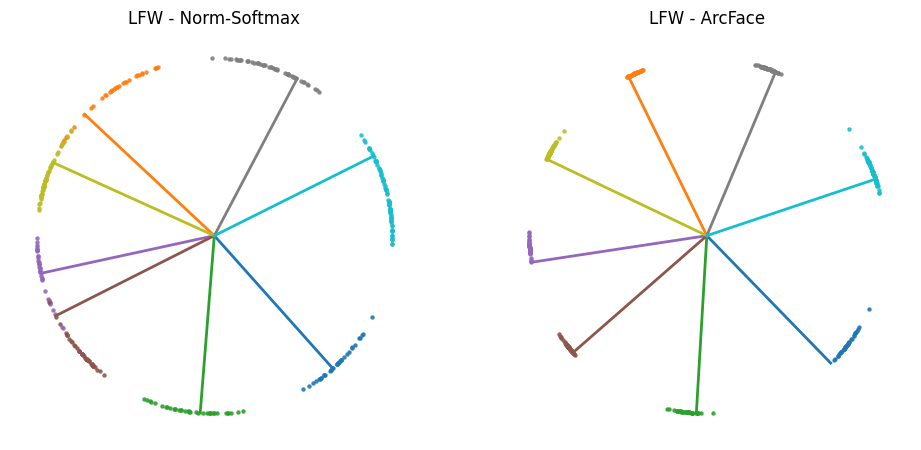

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = total_acc = total = 0
    for feats, labels in loader:
        feats = feats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(feats, labels)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * feats.size(0)
        total_acc += (logits.argmax(dim=1) == labels).sum().item()
        total += feats.size(0)

    return total_loss / total, total_acc / total


@torch.no_grad()
def evaluate(model, loader, device, use_arcface: bool):
    model.eval()
    total_loss = total_acc = total = 0
    for feats, labels in loader:
        feats = feats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_arcface:
            logits, _ = model(feats, labels)
        else:
            logits, _ = model(feats)

        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item() * feats.size(0)
        total_acc += (logits.argmax(dim=1) == labels).sum().item()
        total += feats.size(0)

    return total_loss / total, total_acc / total


@torch.no_grad()
def collect_embeddings(model, loader, device):
    model.eval()
    all_emb, all_y = [], []
    for feats, labels in loader:
        feats = feats.to(device, non_blocking=True)
        emb = model.embedder(feats)
        all_emb.append(emb.cpu())
        all_y.append(labels)

    emb = torch.cat(all_emb, dim=0).numpy()
    y = torch.cat(all_y, dim=0).numpy()
    w = F.normalize(model.head.weight.detach().cpu(), p=2, dim=1).numpy()
    return emb, y, w


def train_arcface_vs_normsoftmax():
    cfg = Config()
    set_seed(cfg.seed)
    print(cfg)

    train_loader, test_loader, in_dim, chosen_names = build_feature_dataloaders(cfg)

    norm_model = NormSoftmaxModel(
        in_dim, cfg.embedding_dim, cfg.num_identities, cfg.norm_scale_s
    ).to(cfg.device)
    arc_model = ArcFaceModel(
        in_dim, cfg.embedding_dim, cfg.num_identities, cfg.arc_scale_s, cfg.arc_margin_m
    ).to(cfg.device)
    norm_optim = torch.optim.AdamW(
        norm_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )
    arc_optim = torch.optim.AdamW(
        arc_model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    print("\nTraining Norm-Softmax")
    best_norm_state = None
    best_norm_te_acc = -1.0
    for epoch in range(cfg.epochs):
        tr_loss, tr_acc = train_one_epoch(
            norm_model,
            train_loader,
            norm_optim,
            cfg.device,
        )
        te_loss, te_acc = evaluate(
            norm_model, test_loader, cfg.device, use_arcface=False
        )
        if te_acc > best_norm_te_acc:
            best_norm_te_acc = te_acc
            best_norm_state = {
                k: v.detach().cpu().clone() for k, v in norm_model.state_dict().items()
            }

        print(
            f"[NormSoftmax] epoch {epoch+1:02d}/{cfg.epochs} | train loss={tr_loss:.4f} acc={tr_acc:.4f} | test loss={te_loss:.4f} acc={te_acc:.4f}"
        )

    print("\nTraining ArcFace")
    arc_model.embedder.load_state_dict(norm_model.embedder.state_dict())
    arc_model.head.weight.data.copy_(norm_model.head.weight.data)
    best_arc_state = None
    best_arc_te_acc = -1.0
    for epoch in range(cfg.epochs):
        warmup = min(1.0, (epoch + 1) / cfg.arc_margin_warmup_epochs)
        arc_model.head.set_margin(cfg.arc_margin_m * warmup)
        tr_loss, tr_acc = train_one_epoch(
            arc_model, train_loader, arc_optim, cfg.device
        )
        te_loss, te_acc = evaluate(
            arc_model, test_loader, cfg.device, use_arcface=False
        )
        if te_acc > best_arc_te_acc:
            best_arc_te_acc = te_acc
            best_arc_state = {
                k: v.detach().cpu().clone() for k, v in arc_model.state_dict().items()
            }
        print(
            f"[ArcFace] epoch {epoch+1:02d}/{cfg.epochs} | m={arc_model.head.m:.3f} | "
            f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | test loss={te_loss:.4f} acc={te_acc:.4f}"
        )
    if best_arc_state is not None:
        arc_model.load_state_dict(best_arc_state)
    print(
        f"[ArcFace final] best test acc={best_arc_te_acc:.4f} "
        f"with s={cfg.arc_scale_s:.1f}, m={cfg.arc_margin_m:.2f}, lr={cfg.lr:.0e}"
    )
    if best_norm_state is not None:
        norm_model.load_state_dict(best_norm_state)
    print(
        f"[NormSoftmax final] best test acc={best_norm_te_acc:.4f} "
        f"with s={cfg.norm_scale_s:.1f}, lr={cfg.lr:.0e}"
    )

    emb_norm, y_norm, w_norm = collect_embeddings(norm_model, train_loader, cfg.device)
    emb_arc, y_arc, w_arc = collect_embeddings(arc_model, train_loader, cfg.device)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
    plot_embeddings(
        axes[0],
        emb_norm,
        y_norm,
        w_norm,
        title="LFW - Norm-Softmax",
        max_points=cfg.norm_points_to_plot_per_class,
    )
    plot_embeddings(
        axes[1],
        emb_arc,
        y_arc,
        w_arc,
        title="LFW - ArcFace",
        max_points=cfg.arc_points_to_plot_per_class,
    )

    plt.tight_layout()
    plt.show()


train_arcface_vs_normsoftmax()

## 5 ANN


### LSH (Locality-sensitive hashing)

![./assets/lsh.webp](./assets/lsh.webp)

- Идея: хешировать объекты так, чтобы похожие попадали в одинаковые buckets
- Используются специальные хеш-функции, сохраняющие близость (например, для косинусного сходства).
- Поиск: сравниваются только элементы из тех же корзин.
- Плюсы: очень быстрый, хорошо масштабируется.
- Минусы: точность ниже, требует настройки хешей.

Примеры функций:
- *Random Hyperplane / **SimHash***
  - Идея: разбить пространство случайными гиперплоскостями
  - Для каждой гиперплоскости проверяется знак скалярного произведения
  - Из нескольких гиперплоскостей получается битовая сигнатура (хеш)
- *MinHash*
- *p-stable LSH*


### HNSW (Hierarchical Navigable Small World)
![./assets/hnsw.png](./assets/hnsw.png)

- Идея: граф, где вершины — объекты, а рёбра соединяют близкие элементы
- Строится многоуровневая структура (от грубой к точной)
- Поиск: начинается сверху и спускается к ближайшим узлам
- Плюсы: высокая точность + скорость
- Минусы: сложнее в реализации, требует памяти на граф, плохо, если много вставок / удалений


**Другие примеры:**
- IVF-PQ
- IVF
- K-D tree


### Библиотеки
- [Annoy](https://github.com/spotify/annoy)
- [FAISS](https://github.com/facebookresearch/faiss)
- [HNSWlib](https://github.com/nmslib/hnswlib)
- [Qdrant](https://github.com/qdrant/qdrant)

In [ ]:
# Задача
# https://github.com/deepinsight/insightface/tree/master/recognition/arcface_torch
# Посчитать эмбединги для лиц, засунуть их в ANN (например hnswlib)
# Сделать поиск по базе
# для препроцессинга изображений может понадобиться следующий код:


# import cv2
# import numpy as np
# import torch
# from skimage import transform as trans


# ARC_FACE_DST = np.array([
#     [38.2946, 51.6963],  # left eye
#     [73.5318, 51.5014],  # right eye
#     [56.0252, 71.7366],  # nose
#     [41.5493, 92.3655],  # left mouth
#     [70.7299, 92.2041],  # right mouth
# ], dtype=np.float32)


# def estimate_norm(landmark_5: np.ndarray, image_size: int = 112) -> np.ndarray:
#     """
#     Estimate similarity transform from detected 5-point landmarks
#     to the ArcFace canonical template.

#     Args:
#         landmark_5: np.ndarray of shape (5, 2), order:
#             [left_eye, right_eye, nose, left_mouth, right_mouth]
#         image_size: output aligned face size, usually 112

#     Returns:
#         2x3 affine transform matrix
#     """
#     assert landmark_5.shape == (5, 2), "landmark_5 must have shape (5, 2)"

#     dst = ARC_FACE_DST.copy()
#     if image_size != 112:
#         scale = image_size / 112.0
#         dst *= scale

#     tform = trans.SimilarityTransform()
#     tform.estimate(landmark_5, dst)
#     M = tform.params[0:2, :]
#     return M.astype(np.float32)


# def norm_crop(img_bgr: np.ndarray, landmark_5: np.ndarray, image_size: int = 112) -> np.ndarray:
#     """
#     Align and crop face using 5 landmarks.

#     Args:
#         img_bgr: input image in BGR format
#         landmark_5: np.ndarray of shape (5, 2)
#         image_size: output size, usually 112

#     Returns:
#         aligned face as BGR image of shape (image_size, image_size, 3)
#     """
#     M = estimate_norm(landmark_5, image_size=image_size)
#     aligned = cv2.warpAffine(
#         img_bgr,
#         M,
#         (image_size, image_size),
#         borderValue=0.0
#     )
#     return aligned


# def arcface_preprocess(
#     img_bgr: np.ndarray,
#     landmark_5: np.ndarray | None = None,
#     image_size: int = 112,
#     return_face: bool = False,
# ) -> torch.Tensor | tuple[torch.Tensor, np.ndarray]:
#     """
#     Preprocess image for ArcFace Torch.

#     If landmark_5 is provided, performs alignment first.
#     Otherwise just resizes to image_size x image_size.

#     Args:
#         img_bgr: input image in BGR format
#         landmark_5: optional facial landmarks, shape (5, 2)
#         image_size: output size, usually 112
#         return_face: if True, also returns aligned/resized face image

#     Returns:
#         torch.Tensor of shape (1, 3, H, W), float32, normalized to [-1, 1]
#         optionally also returns aligned face image
#     """
#     if landmark_5 is not None:
#         face_bgr = norm_crop(img_bgr, landmark_5, image_size=image_size)
#     else:
#         face_bgr = cv2.resize(img_bgr, (image_size, image_size))

#     # BGR -> RGB
#     face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)

#     # HWC -> CHW
#     face_chw = np.transpose(face_rgb, (2, 0, 1)).astype(np.float32)

#     # To tensor and normalize to [-1, 1]
#     tensor = torch.from_numpy(face_chw).unsqueeze(0)
#     tensor.div_(255.0).sub_(0.5).div_(0.5)

#     if return_face:
#         return tensor, face_bgr
#     return tensor